In [36]:
import pandas as pd

# Loaing main data
df = pd.read_csv('analysis_ready.csv')


In [37]:
#Importing Main Libraries
# Core
import pandas as pd
import numpy as np

# Stats
from scipy.stats import ttest_ind
import statsmodels.api as sm

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
df.head()
# There is a brand column, with prices data, segmentation, Model Number, Color, specifications and ratings

,Brand,Model,Color,selling_price,original_price,discount_pct,discount_group,price_segment,brand_tier,storage_tier,ram_gb,storage_gb,Rating,has_rating
0,OPPO,A53,Moonlight Black,11990,15990,25.02,Moderate,Budget,Budget,Low Storage,4,64,4.5,1
1,OPPO,A53,Mint Cream,11990,15990,25.02,Moderate,Budget,Budget,Low Storage,4,64,4.5,1
2,OPPO,A53,Moonlight Black,13990,17990,22.23,Moderate,Budget,Budget,Medium Storage,6,128,4.3,1
3,OPPO,A53,Mint Cream,13990,17990,22.23,Moderate,Budget,Budget,Medium Storage,6,128,4.3,1
4,OPPO,A53,Electric Black,11990,15990,25.02,Moderate,Budget,Budget,Low Storage,4,64,4.5,1


In [39]:
df.info()
# we have integer type in selling price and original price, with float in rating, has_rating, and discount_pct

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2841 entries, 0 to 2840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           2841 non-null   object 
 1   Model           2841 non-null   object 
 2   Color           2841 non-null   object 
 3   selling_price   2841 non-null   int64  
 4   original_price  2841 non-null   int64  
 5   discount_pct    2841 non-null   float64
 6   discount_group  2841 non-null   object 
 7   price_segment   2841 non-null   object 
 8   brand_tier      2841 non-null   object 
 9   storage_tier    2841 non-null   object 
 10  ram_gb          2841 non-null   int64  
 11  storage_gb      2841 non-null   int64  
 12  Rating          2725 non-null   float64
 13  has_rating      2841 non-null   int64  
dtypes: float64(2), int64(5), object(7)
memory usage: 310.9+ KB


In [40]:
df.shape
# there are 14 columns and 2841 rows

(2841, 14)

In [41]:
df.describe()
# the mean for selling price is 25849n and dicount pct is 6.3 %. We also have the mean rating as 4.23

,selling_price,original_price,discount_pct,ram_gb,storage_gb,Rating,has_rating
count,2841.000000,2841.000000,2841.000000,2841.000000,2841.000000,2725.000000,2841.000000
mean,25849.750792,27797.238296,6.318325,14.722281,87.767687,4.236807,0.959169
std,28885.173345,30447.585373,10.925966,73.082415,90.367740,0.272422,0.197933
min,1000.000000,1000.000000,0.000000,1.000000,0.000000,2.300000,0.000000
25%,9999.000000,10800.000000,0.000000,3.000000,32.000000,4.100000,1.000000
50%,15000.000000,16900.000000,0.000000,4.000000,64.000000,4.300000,1.000000
75%,27810.000000,29999.000000,10.000000,6.000000,128.000000,4.400000,1.000000
max,179900.000000,189999.000000,70.610000,768.000000,512.000000,5.000000,1.000000


In [42]:
# standardizing column names:
df.columns = df.columns.str.lower().str.strip()

In [43]:
# Check new column names
print("Columns after standardizing:")
print(df.columns.tolist())

# Quick check
print(f"\nFirst few rows:")
print(df.head())

Columns after standardizing:
['brand', 'model', 'color', 'selling_price', 'original_price', 'discount_pct', 'discount_group', 'price_segment', 'brand_tier', 'storage_tier', 'ram_gb', 'storage_gb', 'rating', 'has_rating']

First few rows:
  brand model            color  selling_price  original_price  discount_pct  \
0  OPPO   A53  Moonlight Black          11990           15990         25.02   
1  OPPO   A53       Mint Cream          11990           15990         25.02   
2  OPPO   A53  Moonlight Black          13990           17990         22.23   
3  OPPO   A53       Mint Cream          13990           17990         22.23   
4  OPPO   A53   Electric Black          11990           15990         25.02   

  discount_group price_segment brand_tier    storage_tier  ram_gb  storage_gb  \
0       Moderate        Budget     Budget     Low Storage       4          64   
1       Moderate        Budget     Budget     Low Storage       4          64   
2       Moderate        Budget     Budget  M

In [44]:
# we check for missing values:
df.isnull().sum()
# missing values are only in ratings, we can confirm first


,0
brand,0
model,0
color,0
selling_price,0
original_price,0
discount_pct,0
discount_group,0
price_segment,0
brand_tier,0
storage_tier,0


In [12]:
# Look at rows with missing ratings
missing_ratings = df[df['rating'].isnull()]

print(f"Products with missing ratings: {len(missing_ratings)}")
print("\nFirst few:")
print(missing_ratings.head())
#  here missing ratings are those ratings NaN

Products with missing ratings: 116

First few:
    brand model          color  selling_price  original_price  discount_pct  \
37   OPPO   A16     Pearl Blue          13850           13850          0.00   
41   OPPO   A16  CRYSTAL BLACK          13990           15990         12.51   
128  OPPO   A16  Crystal Black          13490           13490          0.00   
143  OPPO  F19s   Glowing Gold          19990           22990         13.05   
144  OPPO  F19s  Glowing Black          19990           22990         13.05   

    discount_group price_segment brand_tier    storage_tier  ram_gb  \
37             Low        Budget     Budget     Low Storage       4   
41        Moderate        Budget     Budget     Low Storage       4   
128            Low        Budget     Budget     Low Storage       4   
143       Moderate           Mid     Budget  Medium Storage       6   
144       Moderate           Mid     Budget  Medium Storage       6   

     storage_gb  rating  has_rating  
37           

In [13]:
# Pattern of missing ratings
missing_ratings = df[df['rating'].isnull()]

print("Missing ratings by discount group:")
print(missing_ratings['discount_group'].value_counts())

print("\nMissing ratings by price segment:")
print(missing_ratings['price_segment'].value_counts())

Missing ratings by discount group:
discount_group
Low         83
Moderate    33
Name: count, dtype: int64

Missing ratings by price segment:
price_segment
Premium    58
Budget     32
Mid        26
Name: count, dtype: int64


In [14]:
# checking and confirming data types:
df.dtypes
# all necessary values of columns for analysis are numerical

,0
brand,object
model,object
color,object
selling_price,int64
original_price,int64
discount_pct,float64
discount_group,object
price_segment,object
brand_tier,object
storage_tier,object


In [45]:
# Rated subset (for rating-based analysis)
df_rated = df[df['rating'].notna()].copy()

# Filled version (for correlation & regression)
df['rating_filled'] = df['rating'].fillna(df['rating'].median())

In [16]:
# Verifying datasets

print(f"Full dataset: {len(df)} products")
print(f"Rated dataset: {len(df_rated)} products")
print(f"Unrated products: {len(df) - len(df_rated)}")

# Check missing values
print(f"\nMissing ratings in full dataset: {df['rating'].isnull().sum()}")
print(f"Missing ratings in rated dataset: {df_rated['rating'].isnull().sum()}")

Full dataset: 2841 products
Rated dataset: 2725 products
Unrated products: 116

Missing ratings in full dataset: 116
Missing ratings in rated dataset: 0


In [46]:
# Rating distribution (only rated products)

print("\nRating distribution:")
print(df_rated['rating'].value_counts().sort_index())

# Quick stats
print(f"\nMean: {df_rated['rating'].mean():.2f}")
print(f"Median: {df_rated['rating'].median():.2f}")
print(f"Min: {df_rated['rating'].min()}")
print(f"Max: {df_rated['rating'].max()}")
print(f"Std Dev: {df_rated['rating'].std():.2f}")


Rating distribution:
rating
2.3      1
2.4      1
2.7      2
2.8      3
3.0      6
3.1      2
3.2      3
3.3      8
3.4      3
3.5     17
3.6     34
3.7     63
3.8    105
3.9    118
4.0    205
4.1    229
4.2    291
4.3    650
4.4    494
4.5    290
4.6    147
4.7     44
4.8      2
4.9      1
5.0      6
Name: count, dtype: int64

Mean: 4.24
Median: 4.30
Min: 2.3
Max: 5.0
Std Dev: 0.27


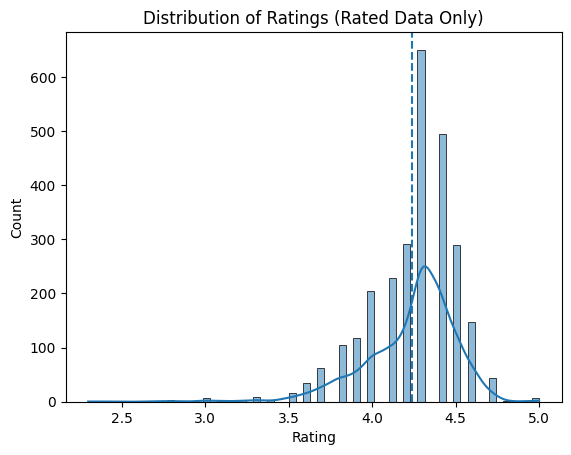

In [47]:
sns.histplot(df_rated['rating'], kde=True)
plt.axvline(df_rated['rating'].mean(), linestyle='--')
plt.title("Distribution of Ratings (Rated Data Only)")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Q1 (25th percentile): 4.1
Q3 (75th percentile): 4.4
IQR: 0.3000000000000007

Outlier bounds: 3.65 to 4.85
Outliers: 87 products

Outlier ratings:
rating
2.3     1
2.4     1
2.7     2
2.8     3
3.0     6
3.1     2
3.2     3
3.3     8
3.4     3
3.5    17
3.6    34
4.9     1
5.0     6
Name: count, dtype: int64


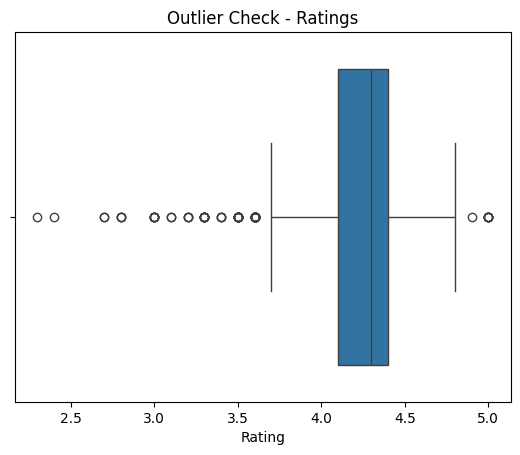

In [19]:
# IQR method for outliers (Rated data only)

Q1 = df_rated['rating'].quantile(0.25)
Q3 = df_rated['rating'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")

# Outlier bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"\nOutlier bounds: {lower:.2f} to {upper:.2f}")

# Count outliers
outliers = df_rated[(df_rated['rating'] < lower) | (df_rated['rating'] > upper)]
print(f"Outliers: {len(outliers)} products")

if len(outliers) > 0:
    print("\nOutlier ratings:")
    print(outliers['rating'].value_counts().sort_index())

# Boxplot (always show, cleaner)
sns.boxplot(x=df_rated['rating'])
plt.title("Outlier Check - Ratings")
plt.xlabel("Rating")
plt.show()

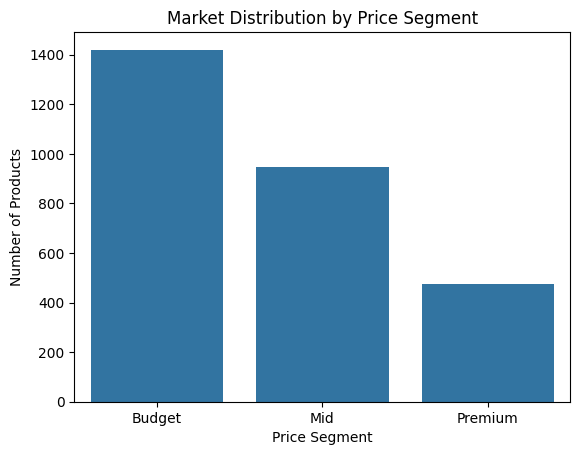

In [48]:
sns.countplot(x='price_segment', data=df)
plt.title("Market Distribution by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Number of Products")
plt.show()

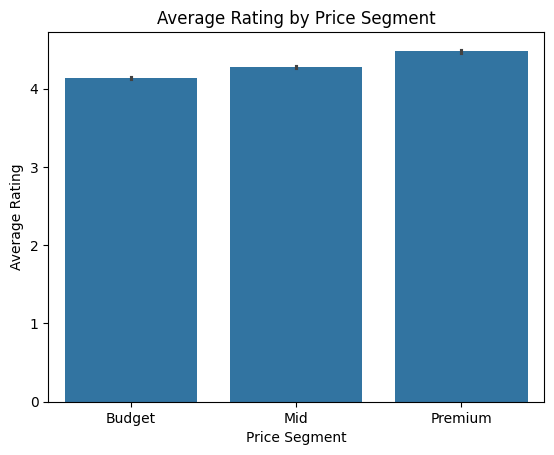

In [49]:
sns.barplot(x='price_segment', y='rating', data=df_rated)
plt.title("Average Rating by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Average Rating")
plt.show()

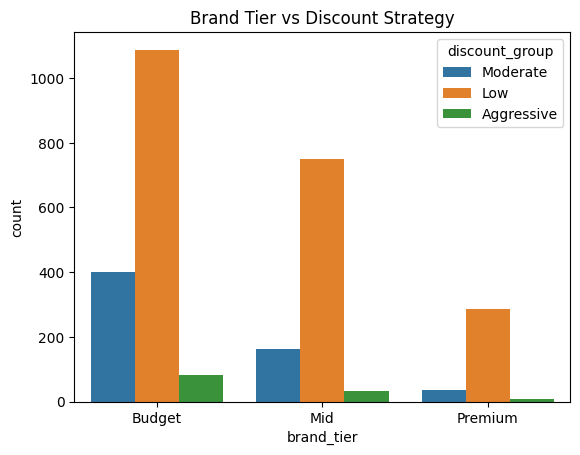

In [22]:
# Brand Tier and Discount Strategy
sns.countplot(x='brand_tier', hue='discount_group', data=df)
plt.title("Brand Tier vs Discount Strategy")
plt.show()

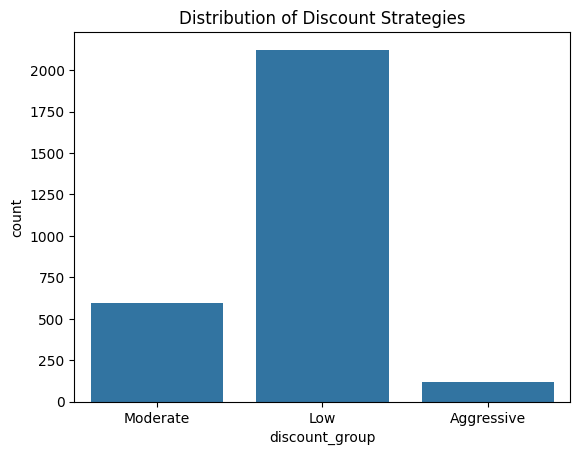

In [23]:
#Discount Strategy Distribution
sns.countplot(x='discount_group', data=df)
plt.title("Distribution of Discount Strategies")
plt.show()

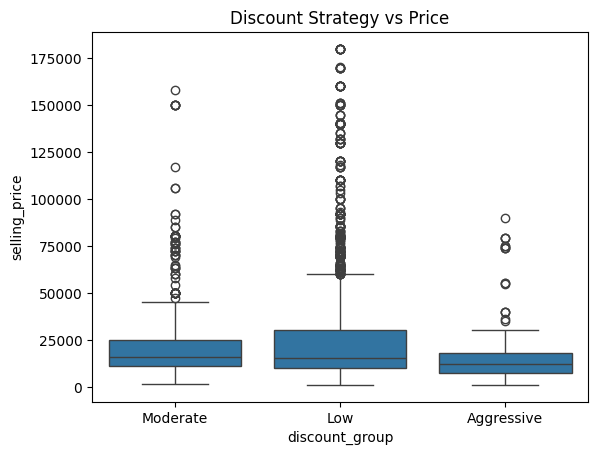

In [25]:
#Discount Strategy vs Price
sns.boxplot(x='discount_group', y='selling_price', data=df)
plt.title("Discount Strategy vs Price")
plt.show()

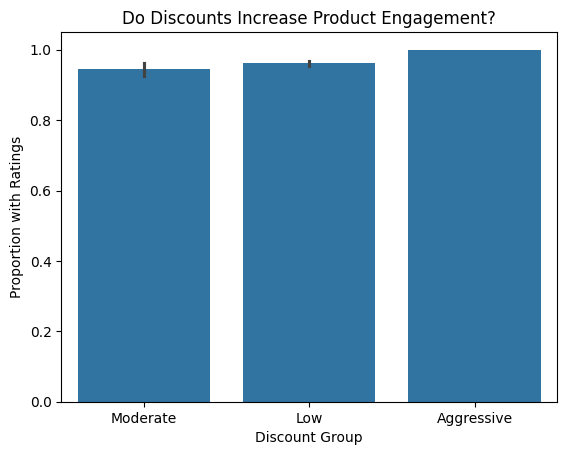

In [50]:
# Discounts impact on product engagement (via Ratings there or not)
sns.barplot(x='discount_group', y='has_rating', data=df)
plt.title("Do Discounts Increase Product Engagement?")
plt.xlabel("Discount Group")
plt.ylabel("Proportion with Ratings")
plt.show()

In [28]:
engagement = df.groupby('discount_group')['has_rating'].mean() * 100
print(engagement)

discount_group
Aggressive    100.000000
Low            96.092279
Moderate       94.463087
Name: has_rating, dtype: float64


In [51]:
# A/B: group sizes
df_rated['discount_group'].value_counts()
# we have enough groups in both

,count
discount_group,
Low,2041
Moderate,563
Aggressive,121


In [52]:
# Define groups
low = df_rated[df_rated['discount_group'] == 'Low']['rating']
high = df_rated[df_rated['discount_group'] == 'Aggressive']['rating']

print("Low mean:", round(low.mean(), 3))
print("High mean:", round(high.mean(), 3))

Low mean: 4.22
High mean: 4.146


In [53]:
# final sanity checks

df_rated[['rating','discount_pct','selling_price']].isnull().sum()

# mean and standard deviation
df_rated.groupby('discount_group')['rating'].agg(['mean','std','count'])

,mean,std,count
discount_group,,,
Aggressive,4.146281,0.320427,121
Low,4.220039,0.285663,2041
Moderate,4.317052,0.179839,563


A/B Testing: Evaluating the Impact of Discount Strategy on Customer Ratings

H₀ (Null Hypothesis):
There is no difference in average ratings between low and aggressive discount groups.

H₁ (Alternative Hypothesis):
There is a difference in average ratings between the two groups.

Method:
A two-sample Welch’s t-test was conducted to compare the mean ratings of products in the low and aggressive discount groups. This test was chosen as it does not assume equal variances between the groups.

Assumption: Samples are independent and approximately normally distributed due to large sample size.

In [54]:
# A/B Testing:

# Defining groups (use rated data only)
low = df_rated[df_rated['discount_group'] == 'Low']['rating']
high = df_rated[df_rated['discount_group'] == 'Aggressive']['rating']

# Checking Means
print("Low:", round(low.mean(), 3))
print("High:", round(high.mean(), 3))

# t-test and p-value
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high, low, equal_var=False)

print("T-stat:", round(t_stat, 3))
print("P-value:", p_value)

Low: 4.22
High: 4.146
T-stat: -2.474
P-value: 0.014617469826642368


In [56]:

# Mean difference
diff = high.mean() - low.mean()

# Standard error
se = np.sqrt(high.var()/len(high) + low.var()/len(low))

# 95% Confidence Interval
ci_low = diff - 1.96 * se
ci_high = diff + 1.96 * se

print("Mean Difference:", round(diff, 3))
print("95% CI:", (round(ci_low, 3), round(ci_high, 3)))

Mean Difference: -0.074
95% CI: (np.float64(-0.132), np.float64(-0.015))


Inferences / Interpretation

The A/B test results indicate a statistically significant difference in average ratings between low and aggressive discount groups (p = 0.014). Products with lower discounts have slightly higher ratings (4.22) compared to aggressively discounted products (4.146).

The 95% confidence interval (-0.132, -0.015) does not include zero, further confirming the statistical significance of this difference.

However, the magnitude of the difference is small (~0.07), suggesting limited practical impact.

Overall, the results indicate that aggressive discounting does not improve customer ratings and may slightly reduce perceived product quality. This highlights a potential trade-off between increased engagement from discounts and perceived value.

Goal:

To understand how discount percentage relates to customer ratings by analyzing the continuous relationship between the two variables.

Method:

A simple linear regression model is used to examine the relationship between discount percentage (independent variable) and product ratings (dependent variable).

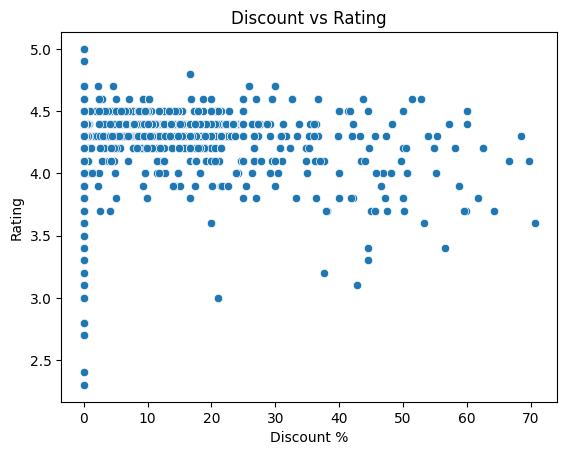

In [55]:

# scatter plot: discount vs rating

sns.scatterplot(x='discount_pct', y='rating_filled', data=df)
plt.title("Discount vs Rating")
plt.xlabel("Discount %")
plt.ylabel("Rating")
plt.show()

In [57]:
import statsmodels.api as sm

# Use full dataset + filled ratings
X = df['discount_pct']
y = df['rating_filled']

# Add constant (intercept)
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          rating_filled   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     8.180
Date:                Wed, 18 Mar 2026   Prob (F-statistic):            0.00427
Time:                        09:39:18   Log-Likelihood:                -276.05
No. Observations:                2841   AIC:                             556.1
Df Residuals:                    2839   BIC:                             568.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.2311      0.006    731.830   

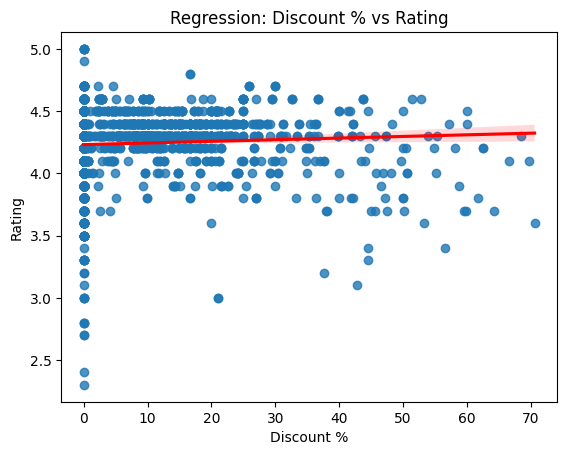

In [58]:

# Regression Graph
sns.regplot(x='discount_pct', y='rating_filled', data=df, line_kws={"color": "red"})
plt.title("Regression: Discount % vs Rating")
plt.xlabel("Discount %")
plt.ylabel("Rating")
plt.show()

The regression coefficient for discount percentage is 0.0014, indicating that for every 1% increase in discount, the rating increases by approximately 0.0014 units.

The p-value (0.004 < 0.05) suggests that this relationship is statistically significant.

However, the R² value of 0.003 indicates that discount percentage explains only 0.3% of the variation in ratings, demonstrating extremely low explanatory power.

Statistically detectable ≠ practically meaningful.

✔ The A/B test shows that high discount products have slightly lower ratings.
✔ The regression indicates a very weak positive relationship between discount percentage and ratings, but the effect is negligible.

Together, these results suggest that while discounting may influence ratings at the extremes, overall discount levels are not a meaningful driver of customer ratings.

## Final Inferences

- Budget and mid-range products dominate the market, with aggressive discounting more common among budget brands.
- Higher discounts increase engagement (more products receive ratings).
- A/B testing shows a statistically significant difference (p < 0.05), with high-discount products having slightly lower ratings.
- The effect size is small, indicating limited practical impact.
- Regression shows a very weak relationship (R² ≈ 0.003), meaning discounts do not meaningfully influence ratings.

**Conclusion:**  
Discounting improves visibility but does not improve customer ratings and may slightly reduce perceived value.